# Demand Filter

This notebook documents the demand-filtering step between product-region outlier filtering and downstream minimum-demand filtering.

Input: `data/interim/transactions_dst_daily_no_outliers`.

The filter is applied at the product-store series level in this order:

1. Remove series with no positive demand.
2. Remove series whose last positive-demand day is more than 365 days before the dataset maximum date.
3. Remove series whose positive-demand active-day share in the last dataset year is below 10%.
4. Remove series with fewer than 15 positive-demand active days over the full active history.

The segment reporting uses the materialized product-region flags from `data/interim/product_sparse_regions/product_sparse_region_flags.parquet` and reports the five retained business groups: FCM 900, FCM 890, Pseudo 900, Pseudo 890 higher velocity, and Pseudo 890 lower intensity.

In [1]:
from pathlib import Path
from io import BytesIO

import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Image

PROJECT_ROOT = next(
    (path.resolve() for path in [Path("../.."), Path(".."), Path(".")] if (path / "src").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the project root containing src/.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "interim" / "transactions_dst_daily_no_outliers"
DATA_GLOB = DATA_DIR / "transactions_year_*.parquet"
REGION_FLAGS_PATH = PROJECT_ROOT / "data" / "interim" / "product_sparse_regions" / "product_sparse_region_flags.parquet"
if not list(DATA_DIR.glob("transactions_year_*.parquet")):
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")
if not REGION_FLAGS_PATH.exists():
    raise FileNotFoundError(f"Missing product-region flags at {REGION_FLAGS_PATH}")

DEMAND_COL = "ABVERKAUFTE_MENGE_KG"
MAX_DAYS_SINCE_LAST_SALE = 365
MIN_LAST_YEAR_DEMAND_ACTIVE_DAY_SHARE = 0.10
MIN_DEMAND_DAYS = 15

ANALYSIS_GROUP_ORDER = [
    "FCM 900",
    "FCM 890",
    "Pseudo 900",
    "Pseudo 890 higher velocity",
    "Pseudo 890 lower intensity",
]
GROUP_COLORS = {
    "FCM 900": "#2a788e",
    "FCM 890": "#c4513b",
    "Pseudo 900": "#5f8f3f",
    "Pseudo 890 higher velocity": "#d7a84b",
    "Pseudo 890 lower intensity": "#7d8588",
}
ANALYSIS_GROUP_LABELS = {
    "FCM 900": "FCM 900",
    "FCM 890": "FCM 890",
    "Pseudo 900": "Pseudo 900",
    "Pseudo 890 higher velocity": "Pseudo 890 höhere Umschlagshäufigkeit",
    "Pseudo 890 lower intensity": "Pseudo 890 niedrigere Intensität",
}
FILTER_ORDER = [
    "no_positive_sale",
    "stale_last_sale",
    "low_last_year_demand_active_day_share",
    "low_demand_days",
    "retained",
]
FILTER_LABELS = {
    "no_positive_sale": "No positive sale",
    "stale_last_sale": "Stale last sale",
    "low_last_year_demand_active_day_share": "Last-year demand share < 10%",
    "low_demand_days": "Demand days < 15",
    "retained": "Retained",
}

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 90)

con = duckdb.connect()
con.execute("PRAGMA threads=8")


def display_figure(fig, dpi=120):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

print(f"Reading daily data from {DATA_GLOB}")
print(f"Reading product-region flags from {REGION_FLAGS_PATH}")

Reading daily data from /Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/transactions_dst_daily_no_outliers/transactions_year_*.parquet
Reading product-region flags from /Users/vlada/UNI/SoSe2026/ba/ba_code/data/interim/product_sparse_regions/product_sparse_region_flags.parquet


## 1. Source Population

The source has already passed product-region outlier filtering. This audit verifies that every active FCM/Pseudo row maps to one of the five retained analysis groups used below.

In [2]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW daily_rows AS
SELECT
    t.ARTIKEL_ID,
    t.MARKT_ID,
    CAST(t.DATE AS DATE) AS period,
    CAST(COALESCE(t.{DEMAND_COL}, 0) AS DOUBLE) AS demand,
    t.is_active,
    t.is_fcm,
    t.is_pseudo,
    t.WGR_ID::INTEGER AS category_id,
    t.MANDANT_ID,
    t.ARTIKEL_BEZ AS product_name,
    flags.region,
    CASE flags.region
        WHEN 'fcm_900_high_intensity' THEN 'FCM 900'
        WHEN 'fcm_890' THEN 'FCM 890'
        WHEN 'pseudo_900_low_intensity' THEN 'Pseudo 900'
        WHEN 'pseudo_890_high_velocity' THEN 'Pseudo 890 higher velocity'
        WHEN 'pseudo_890_low_velocity' THEN 'Pseudo 890 lower intensity'
    END AS analysis_group
FROM read_parquet('{DATA_GLOB}') t
LEFT JOIN read_parquet('{REGION_FLAGS_PATH}') flags USING (ARTIKEL_ID)
WHERE t.is_fcm OR t.is_pseudo
""")

audit = con.execute("""
SELECT
    COUNT(*) AS rows,
    COUNT_IF(is_active) AS active_rows,
    COUNT(DISTINCT ARTIKEL_ID) AS products,
    COUNT(DISTINCT MARKT_ID) AS stores,
    COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
    MIN(period) AS first_date,
    MAX(period) AS max_dataset_date,
    COUNT_IF(ARTIKEL_ID IS NULL OR MARKT_ID IS NULL OR period IS NULL) AS null_keys,
    COUNT_IF(is_fcm IS NULL OR is_pseudo IS NULL) AS null_source_flags,
    COUNT_IF(is_fcm AND is_pseudo) AS overlapping_source_flags,
    COUNT_IF(region IS NULL OR analysis_group IS NULL) AS unmatched_region_rows,
    COUNT_IF(region IN ('fcm_900_low_intensity', 'pseudo_900_high_intensity')) AS excluded_region_rows,
    (SELECT COUNT(*) FROM (
        SELECT ARTIKEL_ID, MARKT_ID, period
        FROM daily_rows
        GROUP BY ALL HAVING COUNT(*) > 1
    )) AS duplicate_series_dates
FROM daily_rows
""").fetchdf()
display(audit)

failure_columns = [
    "null_keys",
    "null_source_flags",
    "overlapping_source_flags",
    "unmatched_region_rows",
    "excluded_region_rows",
    "duplicate_series_dates",
]
if audit[failure_columns].sum(axis=1).iloc[0] != 0:
    raise RuntimeError("Demand-filter source audit failed.")

,rows,active_rows,products,stores,series,first_date,max_dataset_date,null_keys,null_source_flags,overlapping_source_flags,unmatched_region_rows,excluded_region_rows,duplicate_series_dates
0,53452895,44385323.0,668,213,65699,2023-07-22,2026-07-21,0.0,0.0,0.0,0.0,0.0,0


## 2. Series Metrics and Filter Decisions

All rules are computed on active rows. The last-year share uses an inclusive one-year window ending at the dataset maximum date: `period >= max_dataset_date - 365 days`.

In [3]:
series_metrics = con.execute(f"""
WITH dataset_bounds AS (
    SELECT MAX(period) AS max_dataset_date FROM daily_rows
),
series_base AS (
    SELECT
        analysis_group,
        region,
        ARTIKEL_ID,
        MARKT_ID,
        ANY_VALUE(product_name) AS product_name,
        MIN(period) AS first_active_period,
        MAX(period) AS last_active_period,
        MIN(period) FILTER (WHERE demand > 0) AS first_sale_period,
        MAX(period) FILTER (WHERE demand > 0) AS last_sale_period,
        COUNT(*)::BIGINT AS active_days,
        COUNT_IF(demand > 0)::BIGINT AS demand_days,
        COUNT(*) FILTER (
            WHERE period >= (SELECT max_dataset_date FROM dataset_bounds) - INTERVAL {MAX_DAYS_SINCE_LAST_SALE} DAY
        )::BIGINT AS last_year_active_days,
        COUNT_IF(
            period >= (SELECT max_dataset_date FROM dataset_bounds) - INTERVAL {MAX_DAYS_SINCE_LAST_SALE} DAY
            AND demand > 0
        )::BIGINT AS last_year_demand_days,
        SUM(demand)::DOUBLE AS total_demand_kg,
        MAX(demand)::DOUBLE AS max_demand_kg
    FROM daily_rows
    WHERE is_active
    GROUP BY analysis_group, region, ARTIKEL_ID, MARKT_ID
)
SELECT
    b.*,
    b.demand_days::DOUBLE / NULLIF(b.active_days, 0) AS demand_day_ratio,
    b.last_year_demand_days::DOUBLE / NULLIF(b.last_year_active_days, 0)
        AS last_year_demand_day_ratio,
    d.max_dataset_date,
    DATE_DIFF('day', b.last_sale_period, d.max_dataset_date) AS days_since_last_sale,
    CASE
        WHEN b.last_sale_period IS NULL THEN 'no_positive_sale'
        WHEN DATE_DIFF('day', b.last_sale_period, d.max_dataset_date) > {MAX_DAYS_SINCE_LAST_SALE}
            THEN 'stale_last_sale'
        WHEN b.last_year_demand_days::DOUBLE / NULLIF(b.last_year_active_days, 0)
             < {MIN_LAST_YEAR_DEMAND_ACTIVE_DAY_SHARE}
            THEN 'low_last_year_demand_active_day_share'
        WHEN b.demand_days < {MIN_DEMAND_DAYS}
            THEN 'low_demand_days'
        ELSE 'retained'
    END AS filter_status,
    CASE
        WHEN b.last_sale_period IS NULL THEN 1
        WHEN DATE_DIFF('day', b.last_sale_period, d.max_dataset_date) > {MAX_DAYS_SINCE_LAST_SALE} THEN 2
        WHEN b.last_year_demand_days::DOUBLE / NULLIF(b.last_year_active_days, 0)
             < {MIN_LAST_YEAR_DEMAND_ACTIVE_DAY_SHARE} THEN 3
        WHEN b.demand_days < {MIN_DEMAND_DAYS} THEN 4
        ELSE 5
    END AS filter_step
FROM series_base b
CROSS JOIN dataset_bounds d
""").fetchdf()
series_metrics["analysis_group"] = pd.Categorical(
    series_metrics["analysis_group"], ANALYSIS_GROUP_ORDER, ordered=True
)
series_metrics["filter_status"] = pd.Categorical(
    series_metrics["filter_status"], FILTER_ORDER, ordered=True
)
series_metrics["filter_label"] = series_metrics["filter_status"].astype(str).map(FILTER_LABELS)
series_metrics["retained"] = series_metrics["filter_status"].eq("retained")

con.register("series_metrics", series_metrics)

overall_filter_summary = (
    series_metrics.groupby("filter_status", observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        active_days=("active_days", "sum"),
        demand_days=("demand_days", "sum"),
        last_year_active_days=("last_year_active_days", "sum"),
        last_year_demand_days=("last_year_demand_days", "sum"),
        demand_kg=("total_demand_kg", "sum"),
    )
    .reset_index()
)
overall_filter_summary["filter"] = overall_filter_summary["filter_status"].astype(str).map(FILTER_LABELS)
overall_filter_summary["series_share"] = overall_filter_summary["series"] / overall_filter_summary["series"].sum()
overall_filter_summary["demand_kg_share"] = overall_filter_summary["demand_kg"] / overall_filter_summary["demand_kg"].sum()
display(overall_filter_summary[[
    "filter", "series", "series_share", "active_days", "demand_days",
    "last_year_active_days", "last_year_demand_days", "demand_kg", "demand_kg_share",
]].style.format({
    "series": "{:,.0f}",
    "series_share": "{:.2%}",
    "active_days": "{:,.0f}",
    "demand_days": "{:,.0f}",
    "last_year_active_days": "{:,.0f}",
    "last_year_demand_days": "{:,.0f}",
    "demand_kg": "{:,.1f}",
    "demand_kg_share": "{:.3%}",
}))

,filter,series,series_share,active_days,demand_days,last_year_active_days,last_year_demand_days,demand_kg,demand_kg_share
0,No positive sale,13,0.02%,"6,720",0,"3,504",0,0.0,0.000%
1,Stale last sale,"12,692",19.32%,"8,817,736","140,650","3,865,492",0,"288,226.6",1.254%
2,Last-year demand share < 10%,"29,583",45.03%,"18,672,406","764,910","8,176,997","240,832","1,067,172.0",4.641%
3,Demand days < 15,"1,402",2.13%,"40,667","8,563","40,667","8,563","6,321.8",0.027%
4,Retained,"22,009",33.50%,"16,847,794","6,429,736","6,427,744","2,402,874","21,630,667.4",94.078%


## 3. Filter Statistics by Segment and Subsegment

Each row shows the first rule that removes a product-store series. Retained series are those passing all four rules.

In [4]:
segment_filter_summary = (
    series_metrics.groupby(["analysis_group", "region", "filter_status"], observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        active_days=("active_days", "sum"),
        demand_days=("demand_days", "sum"),
        last_year_active_days=("last_year_active_days", "sum"),
        last_year_demand_days=("last_year_demand_days", "sum"),
        demand_kg=("total_demand_kg", "sum"),
        first_active_period=("first_active_period", "min"),
        last_active_period=("last_active_period", "max"),
    )
    .reset_index()
)
segment_totals = (
    series_metrics.groupby(["analysis_group", "region"], observed=True)
    .agg(group_series=("ARTIKEL_ID", "size"), group_demand_kg=("total_demand_kg", "sum"))
    .reset_index()
)
segment_filter_summary = segment_filter_summary.merge(
    segment_totals, on=["analysis_group", "region"], how="left"
)
segment_filter_summary["filter"] = segment_filter_summary["filter_status"].astype(str).map(FILTER_LABELS)
segment_filter_summary["series_share_in_group"] = (
    segment_filter_summary["series"] / segment_filter_summary["group_series"]
)
segment_filter_summary["demand_kg_share_in_group"] = (
    segment_filter_summary["demand_kg"] / segment_filter_summary["group_demand_kg"]
)
segment_filter_summary = segment_filter_summary.sort_values(["analysis_group", "region", "filter_status"])

display(segment_filter_summary[[
    "analysis_group", "region", "filter", "series", "series_share_in_group",
    "active_days", "demand_days", "last_year_active_days", "last_year_demand_days",
    "demand_kg", "demand_kg_share_in_group", "first_active_period", "last_active_period",
]].style.format({
    "series": "{:,.0f}",
    "series_share_in_group": "{:.2%}",
    "active_days": "{:,.0f}",
    "demand_days": "{:,.0f}",
    "last_year_active_days": "{:,.0f}",
    "last_year_demand_days": "{:,.0f}",
    "demand_kg": "{:,.1f}",
    "demand_kg_share_in_group": "{:.3%}",
}))

retention_by_segment = (
    series_metrics.assign(sample=np.where(series_metrics["retained"], "after", "removed"))
    .groupby(["analysis_group", "region", "sample"], observed=True)
    .agg(series=("ARTIKEL_ID", "size"), demand_kg=("total_demand_kg", "sum"))
    .reset_index()
)
display(retention_by_segment.style.format({"series": "{:,.0f}", "demand_kg": "{:,.1f}"}))

,analysis_group,region,filter,series,series_share_in_group,active_days,demand_days,last_year_active_days,last_year_demand_days,demand_kg,demand_kg_share_in_group,first_active_period,last_active_period
0,FCM 900,fcm_900_high_intensity,Stale last sale,23,0.63%,"7,908",220,"6,992",0,114.4,0.071%,2025-04-22 00:00:00,2026-07-21 00:00:00
1,FCM 900,fcm_900_high_intensity,Last-year demand share < 10%,571,15.54%,"143,405","8,044","135,711","6,981","3,205.1",1.985%,2025-04-19 00:00:00,2026-07-21 00:00:00
2,FCM 900,fcm_900_high_intensity,Demand days < 15,285,7.76%,"6,356","2,028","6,356","2,028",832.6,0.516%,2026-02-03 00:00:00,2026-07-21 00:00:00
3,FCM 900,fcm_900_high_intensity,Retained,"2,796",76.08%,"755,441","331,975","699,537","305,819","157,346.7",97.429%,2025-04-17 00:00:00,2026-07-21 00:00:00
4,FCM 890,fcm_890,No positive sale,1,0.04%,274,0,274,0,0.0,0.000%,2025-08-25 00:00:00,2026-07-21 00:00:00
5,FCM 890,fcm_890,Stale last sale,2,0.08%,618,2,608,0,2.0,0.005%,2025-07-15 00:00:00,2026-07-21 00:00:00
6,FCM 890,fcm_890,Last-year demand share < 10%,"1,720",67.96%,"352,693","12,780","352,693","12,780","18,339.5",49.508%,2025-08-05 00:00:00,2026-07-21 00:00:00
7,FCM 890,fcm_890,Demand days < 15,489,19.32%,"18,167","3,330","18,167","3,330","2,938.5",7.932%,2026-02-06 00:00:00,2026-07-21 00:00:00
8,FCM 890,fcm_890,Retained,319,12.60%,"67,340","10,279","67,340","10,279","15,763.6",42.554%,2025-09-16 00:00:00,2026-07-21 00:00:00
9,Pseudo 900,pseudo_900_low_intensity,Stale last sale,392,28.99%,"236,765","5,224","119,584",0,"2,693.9",17.724%,2023-07-22 00:00:00,2026-07-21 00:00:00


,analysis_group,region,sample,series,demand_kg
0,FCM 900,fcm_900_high_intensity,after,"2,796","157,346.7"
1,FCM 900,fcm_900_high_intensity,removed,879,"4,152.1"
2,FCM 890,fcm_890,after,319,"15,763.6"
3,FCM 890,fcm_890,removed,"2,212","21,279.9"
4,Pseudo 900,pseudo_900_low_intensity,after,244,"9,685.5"
5,Pseudo 900,pseudo_900_low_intensity,removed,"1,108","5,514.0"
6,Pseudo 890 higher velocity,pseudo_890_high_velocity,after,"11,648","19,811,782.2"
7,Pseudo 890 higher velocity,pseudo_890_high_velocity,removed,"7,301","784,398.0"
8,Pseudo 890 lower intensity,pseudo_890_low_velocity,after,"7,002","1,636,089.4"
9,Pseudo 890 lower intensity,pseudo_890_low_velocity,removed,"32,190","546,376.3"


## 4. Distribution Before and After Filtering

The plots compare all input product-store series before filtering with the retained product-store series after all rules. The same axes are used within each measure so shifts are comparable across segments.

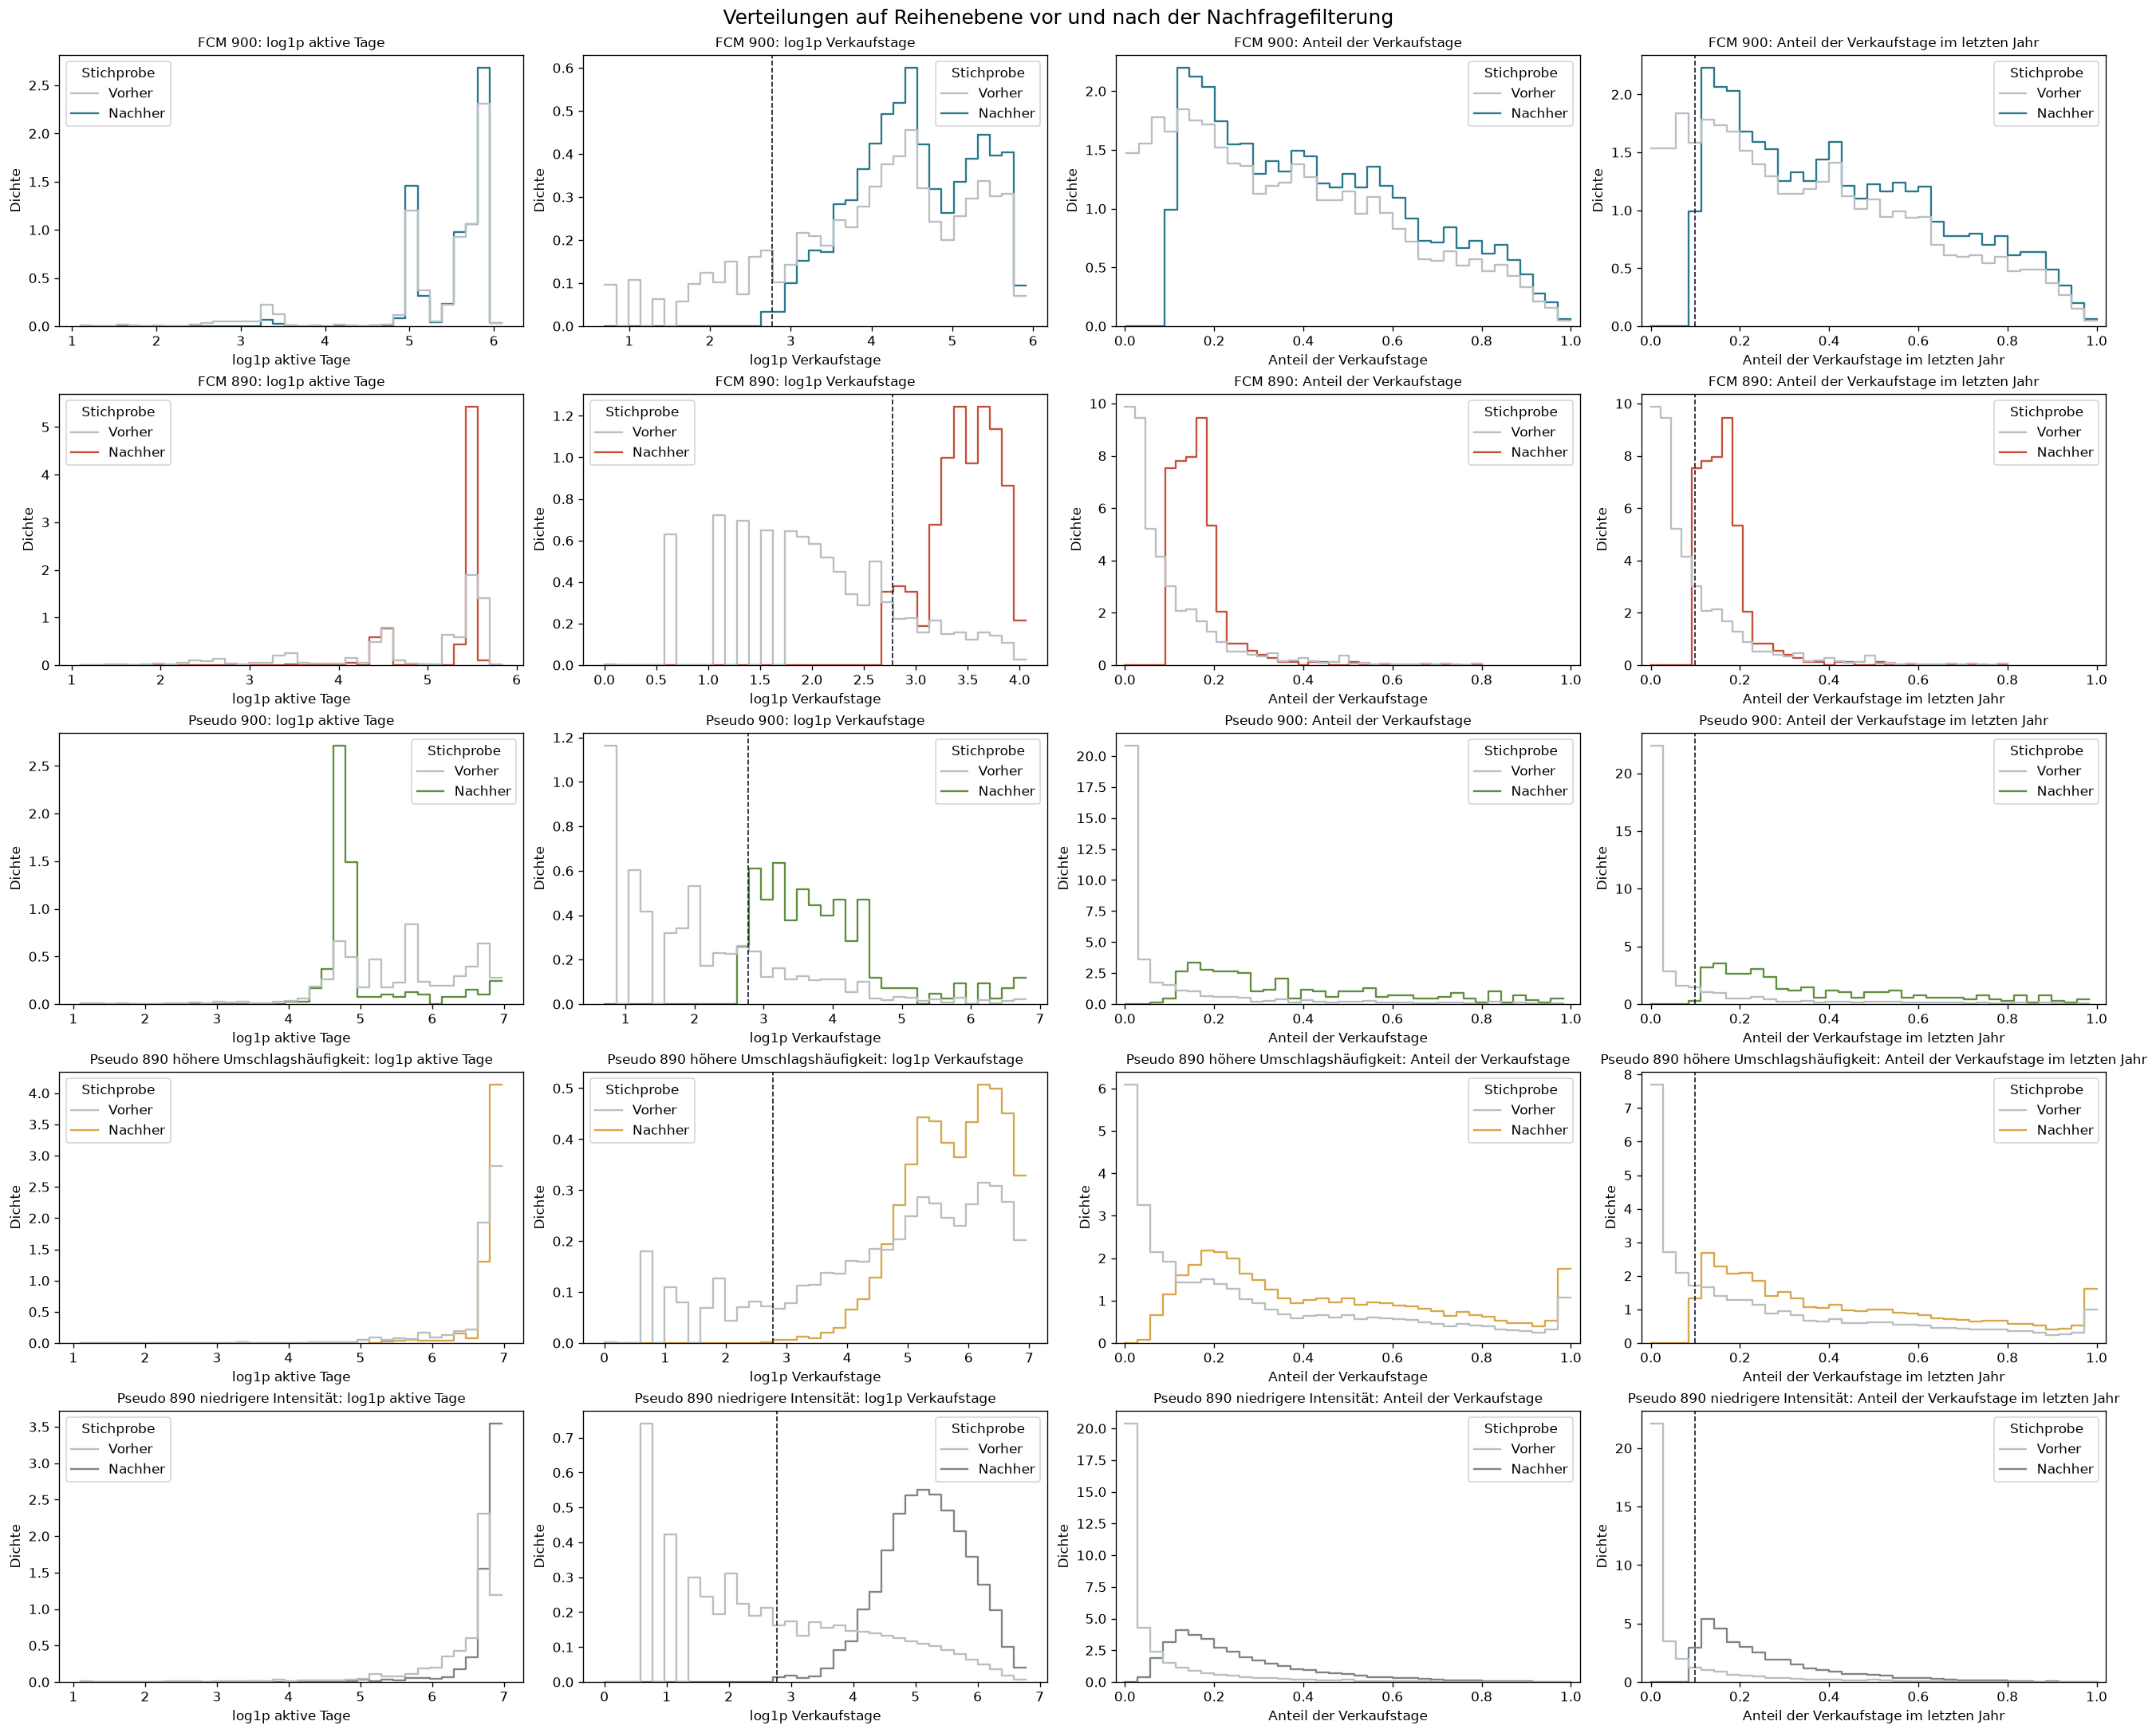

In [5]:
plot_metrics = series_metrics.copy()
plot_metrics["sample"] = np.where(plot_metrics["retained"], "Nachher", "Vorher")
before_plot = plot_metrics.copy()
before_plot["sample"] = "Vorher"
after_plot = plot_metrics[plot_metrics["retained"]].copy()
after_plot["sample"] = "Nachher"
distribution_plot = pd.concat([before_plot, after_plot], ignore_index=True)
distribution_plot["Stichprobe"] = distribution_plot["sample"]

measures = [
    ("active_days", "log1p aktive Tage"),
    ("demand_days", "log1p Verkaufstage"),
    ("demand_day_ratio", "Anteil der Verkaufstage"),
    ("last_year_demand_day_ratio", "Anteil der Verkaufstage im letzten Jahr"),
]
fig, axes = plt.subplots(len(ANALYSIS_GROUP_ORDER), len(measures), figsize=(22, 18), constrained_layout=True)
for row_index, group_name in enumerate(ANALYSIS_GROUP_ORDER):
    group_values = distribution_plot[distribution_plot["analysis_group"] == group_name].copy()
    for col_index, (measure, label) in enumerate(measures):
        ax = axes[row_index, col_index]
        values = group_values.copy()
        plot_measure = measure
        if measure in {"active_days", "demand_days"}:
            plot_measure = f"log_{measure}"
            values[plot_measure] = np.log1p(values[measure])
        sns.histplot(
            data=values,
            x=plot_measure,
            hue="Stichprobe",
            hue_order=["Vorher", "Nachher"],
            stat="density",
            common_norm=False,
            bins=35,
            element="step",
            fill=False,
            linewidth=1.4,
            palette={"Vorher": "#b8bec2", "Nachher": GROUP_COLORS[group_name]},
            ax=ax,
        )
        if measure == "demand_days":
            ax.axvline(np.log1p(MIN_DEMAND_DAYS), color="#111827", linestyle="--", linewidth=1)
        if measure == "last_year_demand_day_ratio":
            ax.axvline(MIN_LAST_YEAR_DEMAND_ACTIVE_DAY_SHARE, color="#111827", linestyle="--", linewidth=1)
            ax.set_xlim(-0.02, 1.02)
        if measure == "demand_day_ratio":
            ax.set_xlim(-0.02, 1.02)
        ax.set_title(f"{ANALYSIS_GROUP_LABELS[group_name]}: {label}", fontsize=10)
        ax.set_xlabel(label)
        ax.set_ylabel("Dichte")
fig.suptitle("Verteilungen auf Reihenebene vor und nach der Nachfragefilterung", fontsize=15)
display_figure(fig)

## 5. Date and Sale-Span Distributions

The date diagnostics mirror the minimum-demand notebook: first-to-last positive-sale span is summarized and plotted before and after filtering, alongside first and last positive-sale date distributions.

,sample,analysis_group,series,no_sale_series,minimum,q25,median,q75,maximum
0,After,FCM 900,"2,796",0,21,181,348,409,461
1,After,FCM 890,319,0,34,161,185,197,212
2,After,Pseudo 900,244,0,20,96,123,147,"1,095"
3,After,Pseudo 890 higher velocity,"11,648",0,29,"1,045","1,089","1,095","1,096"
4,After,Pseudo 890 lower intensity,"7,002",0,30,"1,027","1,082","1,092","1,096"
5,Before,FCM 900,"3,675",0,1,171,299,405,461
6,Before,FCM 890,"2,531",1,1,13,35,159,348
7,Before,Pseudo 900,"1,352",0,1,5,58,180,"1,095"
8,Before,Pseudo 890 higher velocity,"18,949",4,1,761,"1,039","1,093","1,096"
9,Before,Pseudo 890 lower intensity,"39,192",8,1,105,708,"1,009","1,096"


/var/folders/v7/49xgv42x7ld3hqhjfsrsp1lh0000gn/T/ipykernel_24098/3955889507.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(fontsize=8)


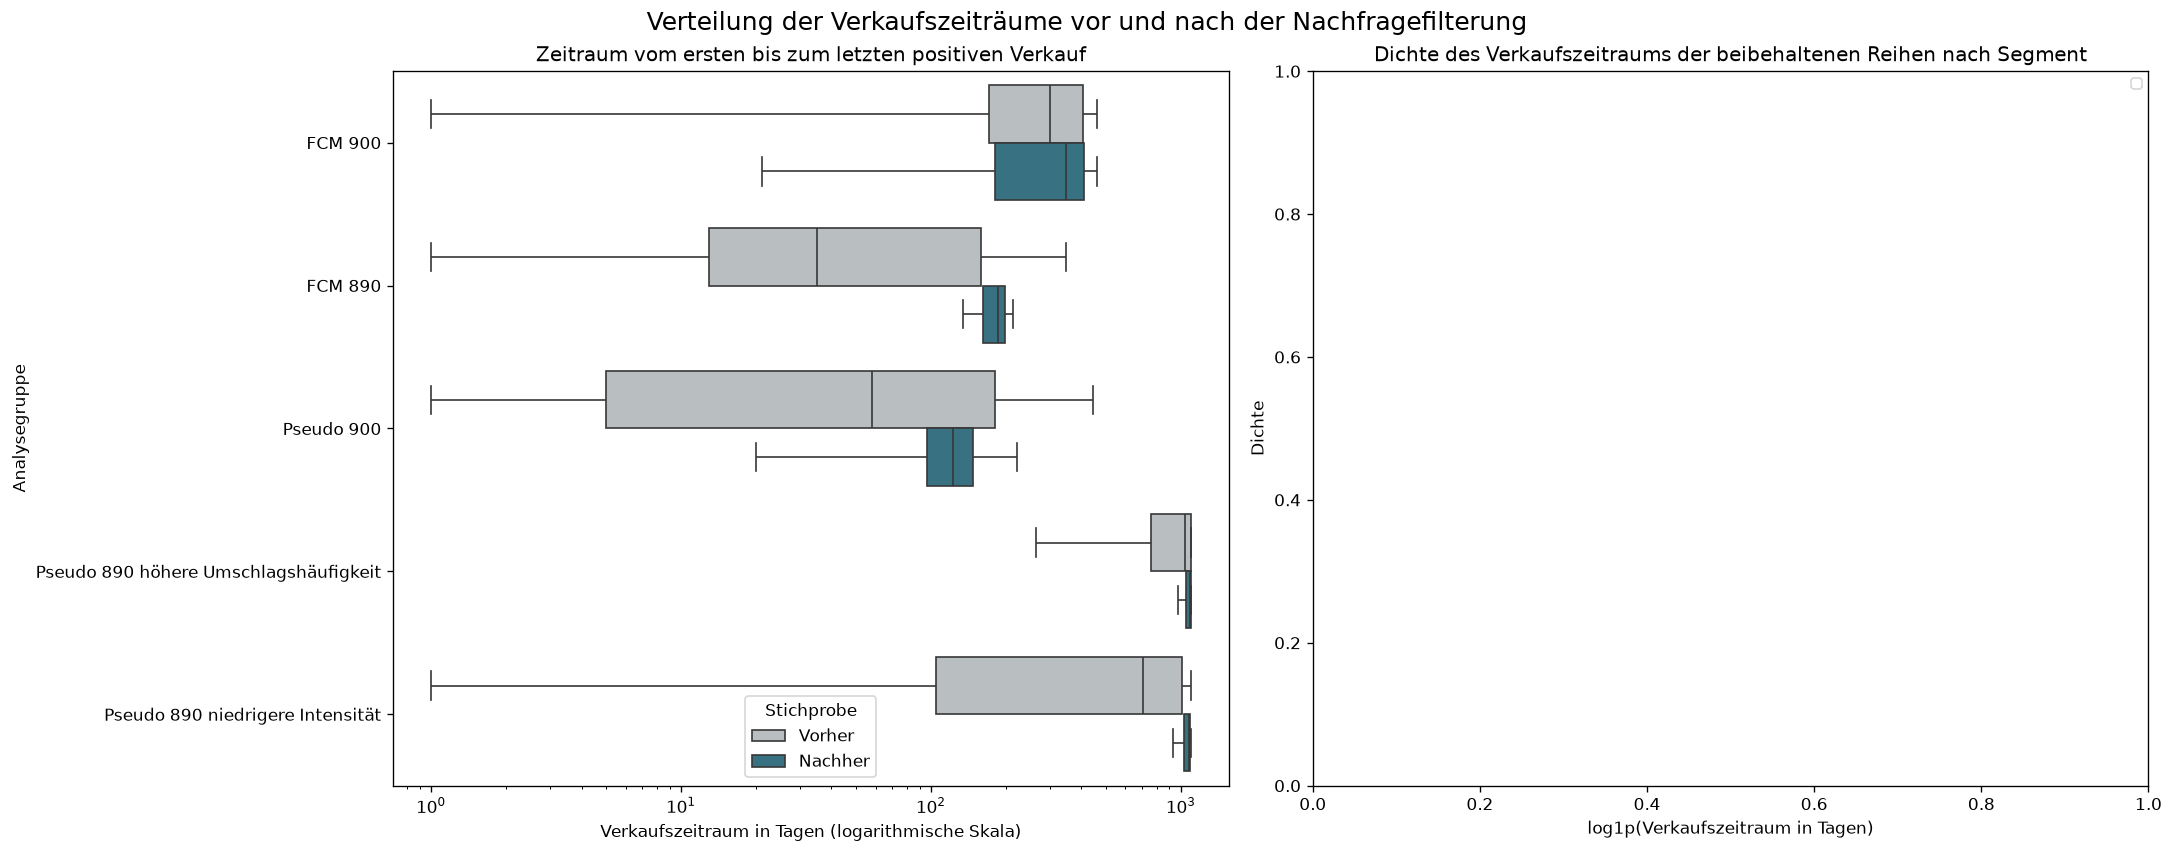

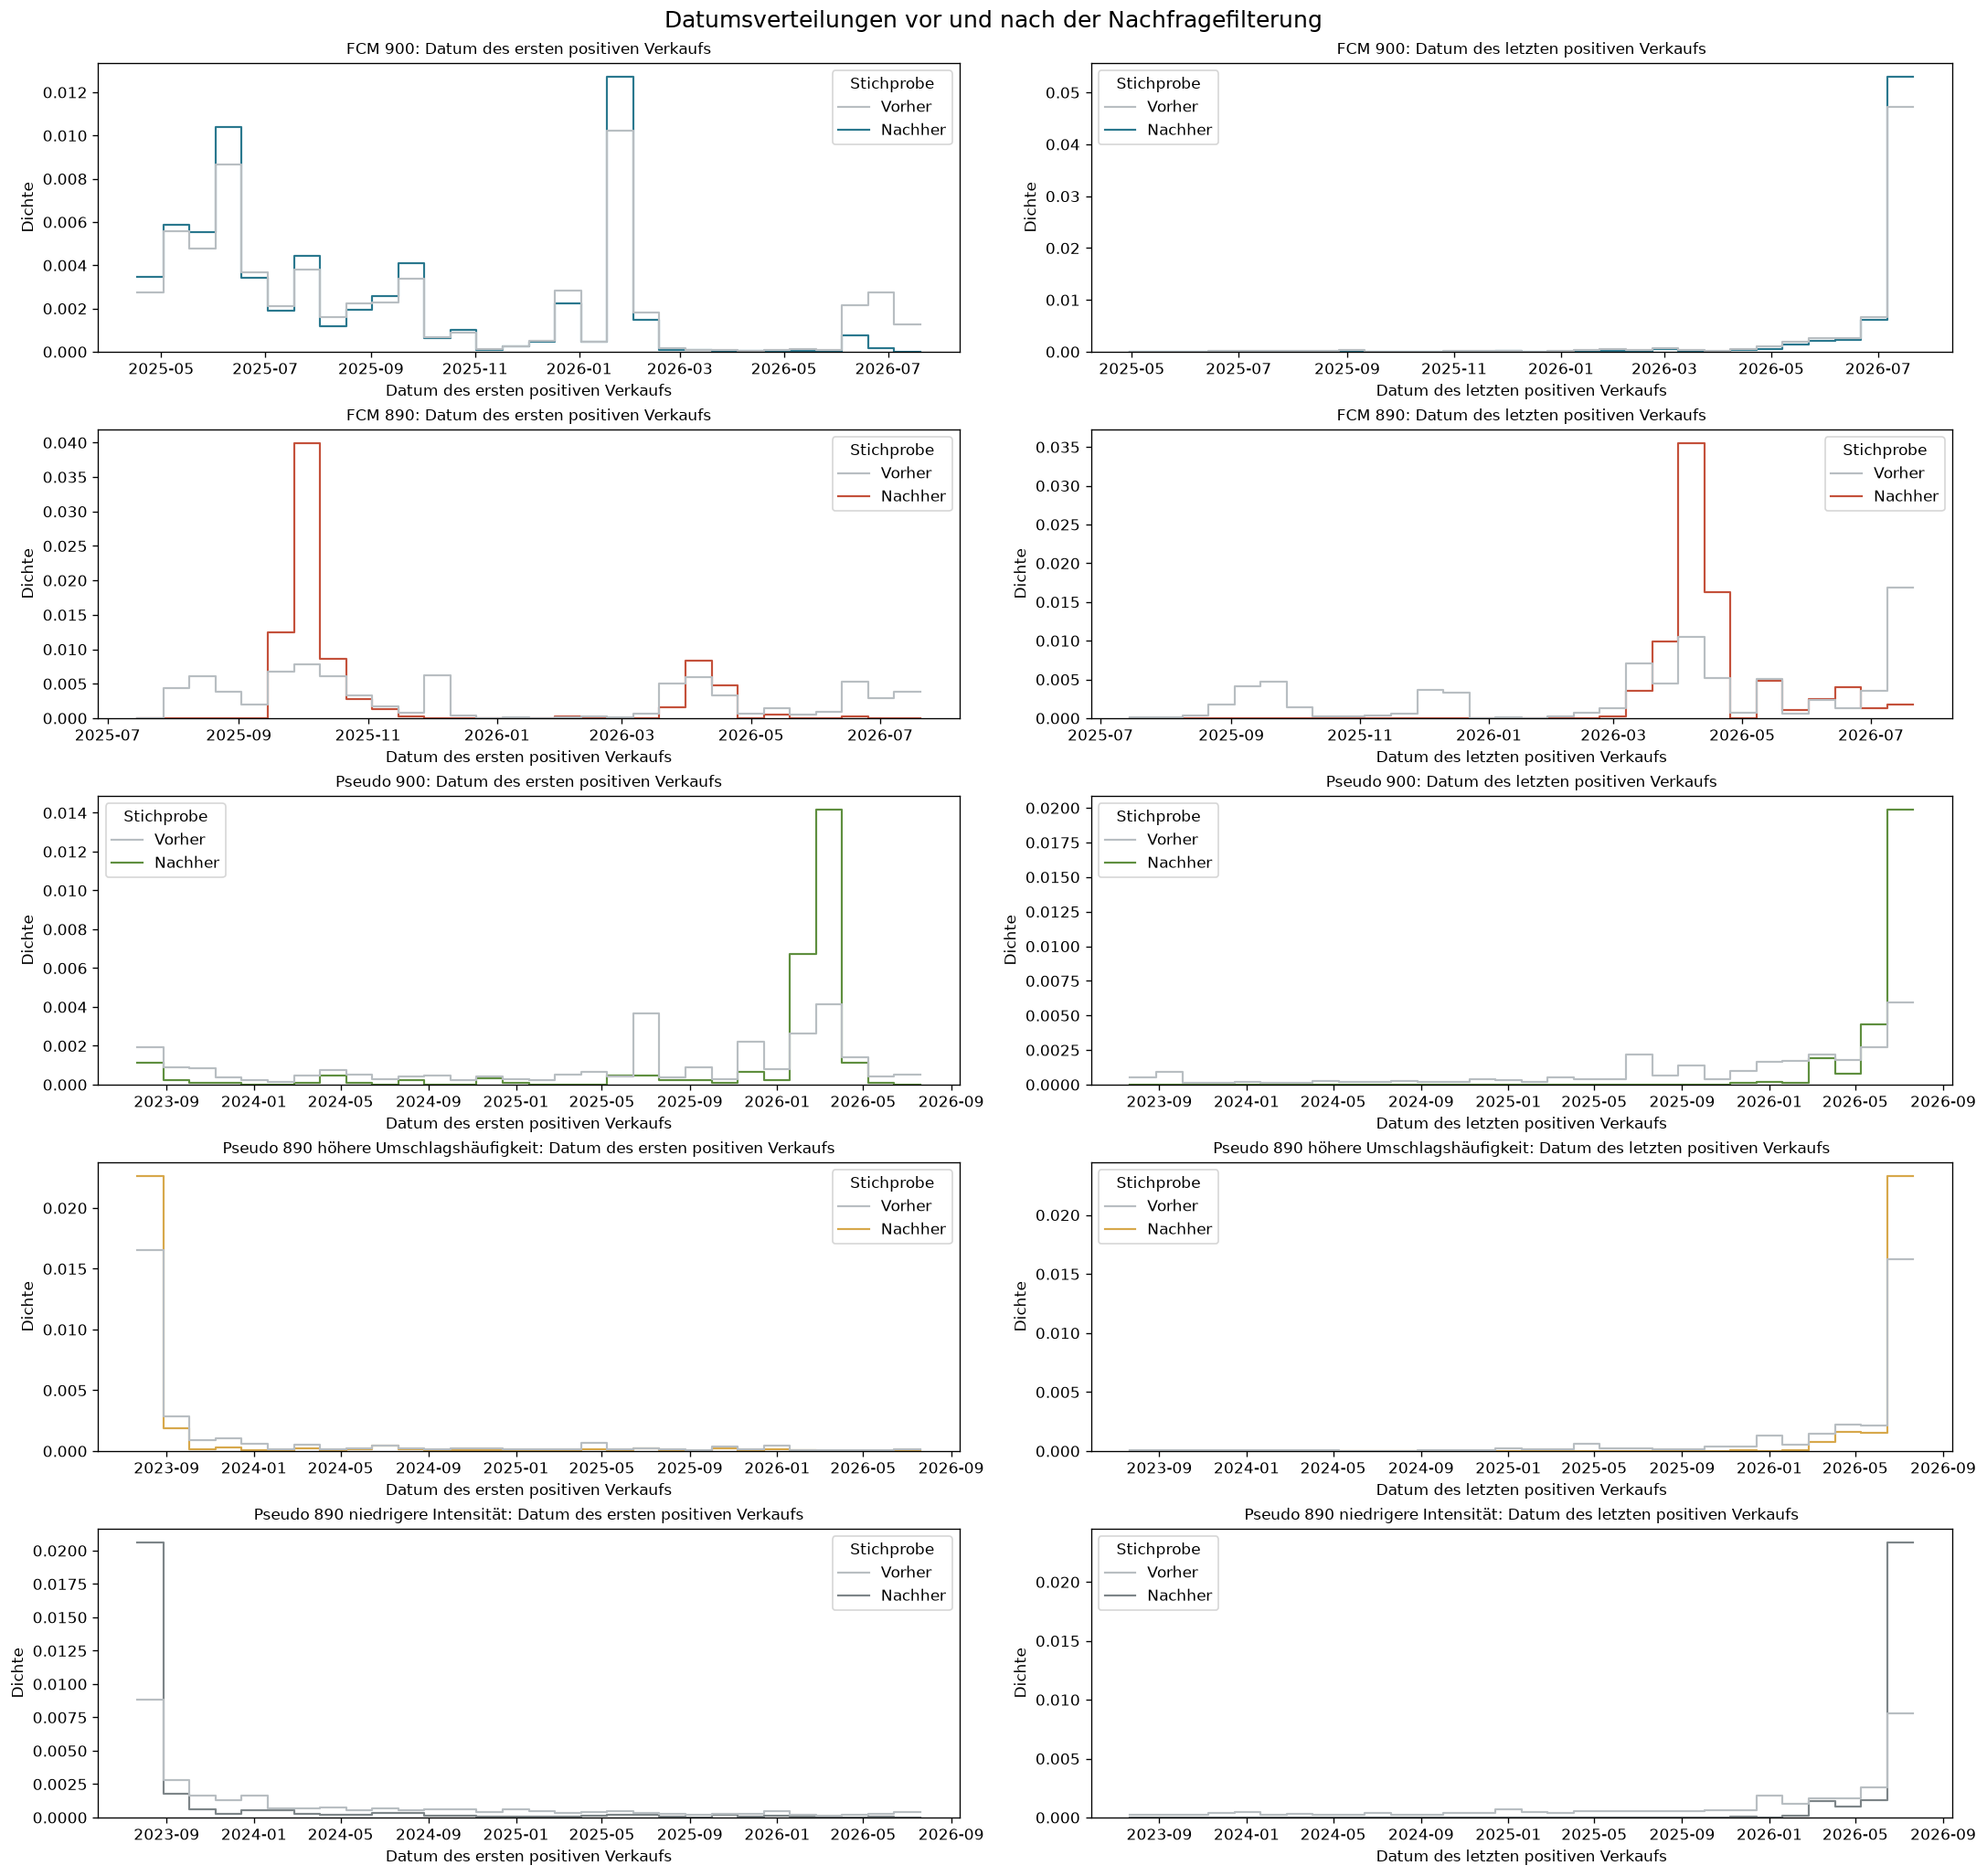

In [6]:
date_plot = pd.concat([
    series_metrics.assign(sample="Before"),
    series_metrics[series_metrics["retained"]].assign(sample="After"),
], ignore_index=True)
date_plot["sale_span_days"] = (
    pd.to_datetime(date_plot["last_sale_period"]) - pd.to_datetime(date_plot["first_sale_period"])
).dt.days + 1
date_plot["Stichprobe"] = date_plot["sample"].map({
    "Before": "Vorher", "After": "Nachher"
})
date_plot["Analysegruppe"] = date_plot["analysis_group"].map(ANALYSIS_GROUP_LABELS)

sale_span_summary = (
    date_plot.groupby(["sample", "analysis_group"], observed=True)
    .agg(
        series=("ARTIKEL_ID", "size"),
        no_sale_series=("sale_span_days", lambda values: values.isna().sum()),
        minimum=("sale_span_days", "min"),
        q25=("sale_span_days", lambda values: values.quantile(0.25)),
        median=("sale_span_days", "median"),
        q75=("sale_span_days", lambda values: values.quantile(0.75)),
        maximum=("sale_span_days", "max"),
    )
    .reset_index()
)
display(sale_span_summary.style.format({
    "series": "{:,.0f}",
    "no_sale_series": "{:,.0f}",
    "minimum": "{:,.0f}",
    "q25": "{:,.0f}",
    "median": "{:,.0f}",
    "q75": "{:,.0f}",
    "maximum": "{:,.0f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
sns.boxplot(
    data=date_plot.dropna(subset=["sale_span_days"]),
    y="Analysegruppe",
    x="sale_span_days",
    hue="Stichprobe",
    order=[ANALYSIS_GROUP_LABELS[group] for group in ANALYSIS_GROUP_ORDER],
    hue_order=["Vorher", "Nachher"],
    showfliers=False,
    palette={"Vorher": "#b8bec2", "Nachher": "#2a788e"},
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_title("Zeitraum vom ersten bis zum letzten positiven Verkauf")
axes[0].set_xlabel("Verkaufszeitraum in Tagen (logarithmische Skala)")
axes[0].set_ylabel("Analysegruppe")

for group_name in ANALYSIS_GROUP_ORDER:
    before = date_plot[(date_plot.analysis_group == group_name) & (date_plot.sample == "Before")].dropna(subset=["sale_span_days"])
    after = date_plot[(date_plot.analysis_group == group_name) & (date_plot.sample == "After")].dropna(subset=["sale_span_days"])
    if not before.empty:
        sns.kdeplot(np.log1p(before.sale_span_days), color="#b8bec2", linewidth=1.0, alpha=0.35, ax=axes[1])
    if not after.empty:
        sns.kdeplot(np.log1p(after.sale_span_days), color=GROUP_COLORS[group_name], linewidth=1.8, label=ANALYSIS_GROUP_LABELS[group_name], ax=axes[1])
axes[1].set_title("Dichte des Verkaufszeitraums der beibehaltenen Reihen nach Segment")
axes[1].set_xlabel("log1p(Verkaufszeitraum in Tagen)")
axes[1].set_ylabel("Dichte")
axes[1].legend(fontsize=8)
fig.suptitle("Verteilung der Verkaufszeiträume vor und nach der Nachfragefilterung", fontsize=15)
display_figure(fig)

fig, axes = plt.subplots(len(ANALYSIS_GROUP_ORDER), 2, figsize=(18, 17), constrained_layout=True)
for row_index, group_name in enumerate(ANALYSIS_GROUP_ORDER):
    group_values = date_plot[date_plot["analysis_group"] == group_name].copy()
    for col_index, (date_col, title) in enumerate([
        ("first_sale_period", "Datum des ersten positiven Verkaufs"),
        ("last_sale_period", "Datum des letzten positiven Verkaufs"),
    ]):
        ax = axes[row_index, col_index]
        values = group_values.dropna(subset=[date_col]).copy()
        values[date_col] = pd.to_datetime(values[date_col])
        sns.histplot(
            data=values,
            x=date_col,
            hue="Stichprobe",
            hue_order=["Vorher", "Nachher"],
            stat="density",
            common_norm=False,
            bins=30,
            element="step",
            fill=False,
            linewidth=1.3,
            palette={"Vorher": "#b8bec2", "Nachher": GROUP_COLORS[group_name]},
            ax=ax,
        )
        ax.set_title(f"{ANALYSIS_GROUP_LABELS[group_name]}: {title}", fontsize=10)
        ax.set_xlabel(title)
        ax.set_ylabel("Dichte")
fig.suptitle("Datumsverteilungen vor und nach der Nachfragefilterung", fontsize=15)
display_figure(fig)

## Conclusion

The demand-filter stage removes inactive forecasting candidates before the later minimum-demand notebook. The four rules are intentionally ordered so each removed series has one primary removal reason: no demand, stale last sale, weak last-year demand activity, or insufficient total demand days. The retained population keeps series with recent demand, at least 10% demand-day share in the final dataset year, and at least 15 positive-demand days overall.